# Motion control on the bench rig — reliable 80 ms telemetry + the control-rate chop

Drives the DeviceBus device subsystem directly (bring-up DEV image) and captures state over the **firmware's
unsolicited `TLM` push stream** (`STREAM <ms>`), not per-sample polling. The push path is **gap-free** — nothing to
drop — so the traces are clean.

**Rig (by inertia):** motor 1 = the **DRUM** (four wheels + OTOS/line/color loads → highest inertia); motor 2 = 3 wheels.

**Three timescales that matter here:**
- **~16 ms** — the DeviceBus fiber tick (runs the velocity PID + writes duty).
- **~80 ms** — the Nezha brick's encoder-refresh period (the light minor gridlines). Position only advances once per 80 ms.
- **300 ms** — the RX deadman (`kVelocityStaleUs`): a velocity setpoint older than this is force-neutralized, so the host
  re-sends VEL every 100 ms to keep driving.

The PID runs at 16 ms against feedback that only refreshes at 80 ms — so it recomputes on stale velocity ~5× per real
measurement. That mismatch is the **chop**, and it shows up as the applied-duty trace hunting within each 80 ms cell.

In [16]:
import sys, pathlib, math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

REPO = pathlib.Path.cwd()
while not (REPO / "pyproject.toml").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "tests" / "bench"))
from rig_dev import Rig, stream_capture

ENCODER_REFRESH_S = 0.080  # Nezha encoder-refresh period + gridline spacing

rig = Rig(settle=3.0)
print("ping:", rig.cmd("PING")[0])
print("otos:", rig.cmd("ODIAG")[0])

ping: OK pong #1
otos: OK conn=1 present=1 txn=3348 err=0 lasterr=0 id=95 #2


In [17]:
def grid80(ax):
    ax.xaxis.set_minor_locator(MultipleLocator(ENCODER_REFRESH_S))
    ax.grid(which="major", alpha=0.45)
    ax.grid(which="minor", axis="x", color="#999", alpha=0.25, lw=0.5)

def arr(rows, k):
    return np.array([r[k] if r[k] is not None else np.nan for r in rows], float)

## 1. Gap-free capture of the drum (motor 1)

One-directional sine (50–250 mm/s, no reversal) so tracking is clean. Streamed at **20 ms** — fast enough to resolve
the 80 ms position staircase *and* the 16 ms-driven duty — while position/velocity still only truly update every 80 ms.

frames=351  rate=43/s  dt[ms] min/med/max=20/22/30  gaps>2x=0


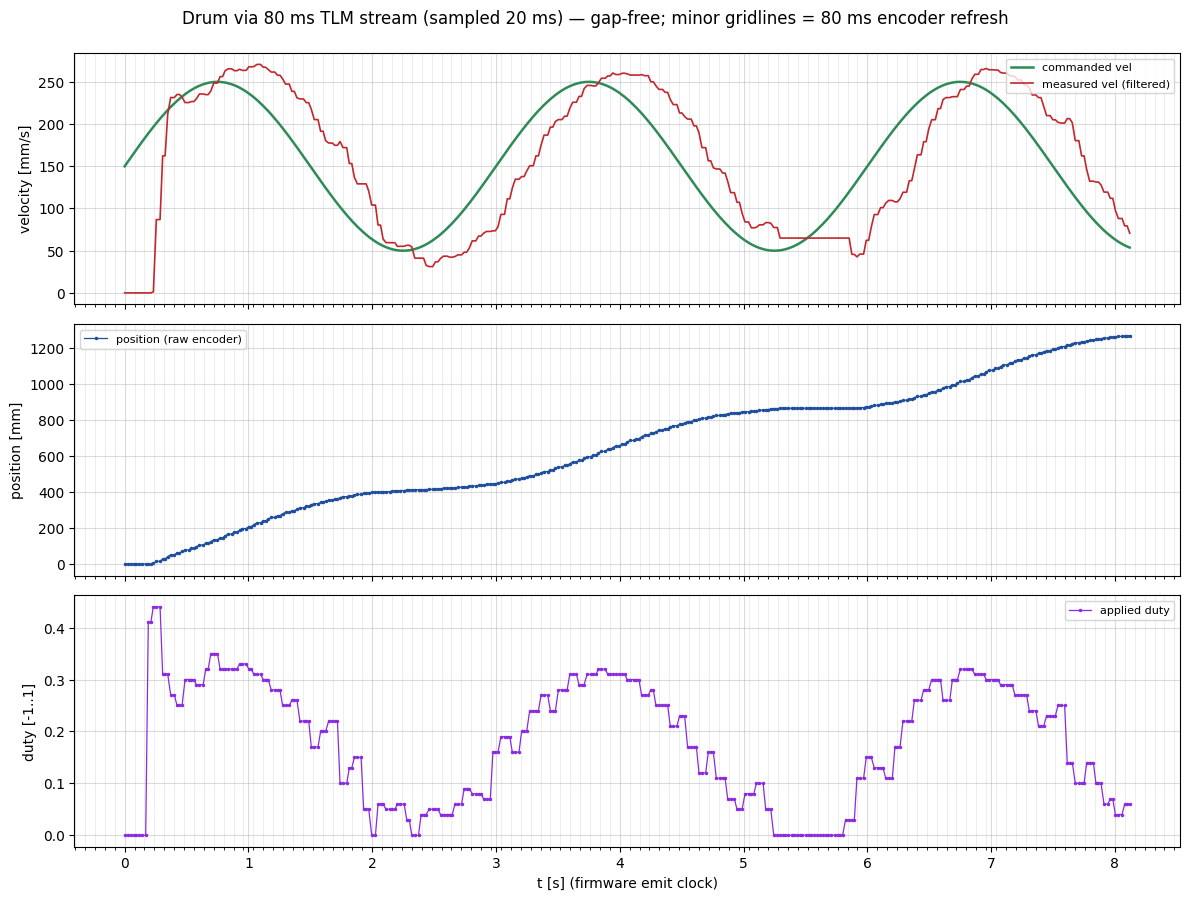

In [18]:
drum = stream_capture(rig, 1, lambda t: 100.0*math.sin(2*math.pi*t/3.0),
                      duration=8.0, stream_ms=20, offset=150.0)
t = arr(drum, "t")
dt = np.diff(t) * 1000
print(f"frames={len(drum)}  rate={len(drum)/t[-1]:.0f}/s  "
      f"dt[ms] min/med/max={dt.min():.0f}/{np.median(dt):.0f}/{dt.max():.0f}  gaps>2x={int((dt>2*np.median(dt)).sum())}")

fig, ax = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
ax[0].plot(t, arr(drum,"cmd"), color="#2e8b57", lw=1.8, label="commanded vel")
ax[0].plot(t, arr(drum,"vel"), color="#c1272d", lw=1.2, label="measured vel (filtered)")
ax[0].set_ylabel("velocity [mm/s]"); ax[0].legend(fontsize=8, loc="upper right")
ax[1].plot(t, arr(drum,"pos"), color="#1f4e9c", lw=0.9, marker=".", ms=3, label="position (raw encoder)")
ax[1].set_ylabel("position [mm]"); ax[1].legend(fontsize=8, loc="upper left")
ax[2].plot(t, arr(drum,"applied"), color="#8a2be2", lw=0.9, marker=".", ms=3, label="applied duty")
ax[2].set_ylabel("duty [-1..1]"); ax[2].set_xlabel("t [s] (firmware emit clock)")
ax[2].legend(fontsize=8, loc="upper right")
for a in ax: grid80(a)
fig.suptitle("Drum via 80 ms TLM stream (sampled 20 ms) — gap-free; minor gridlines = 80 ms encoder refresh", y=0.995)
fig.tight_layout(); plt.show()

## 2. The 80 ms staircase, and how steady the loop actually is

Zoom on a ~1.2 s steady-drive window. **Position** (top) holds flat for ~4 samples then steps — the steps land on the
80 ms gridlines, exactly as expected for an encoder that only refreshes every 80 ms. **Applied duty** (bottom) at a
steady setpoint is actually *tight* (small ripple) — the velocity loop is solid at constant speed. The 16 ms-vs-80 ms
rate mismatch shows up mainly as extra duty motion during fast command *changes* on the high-inertia drum, not as a
steady-state limit cycle.

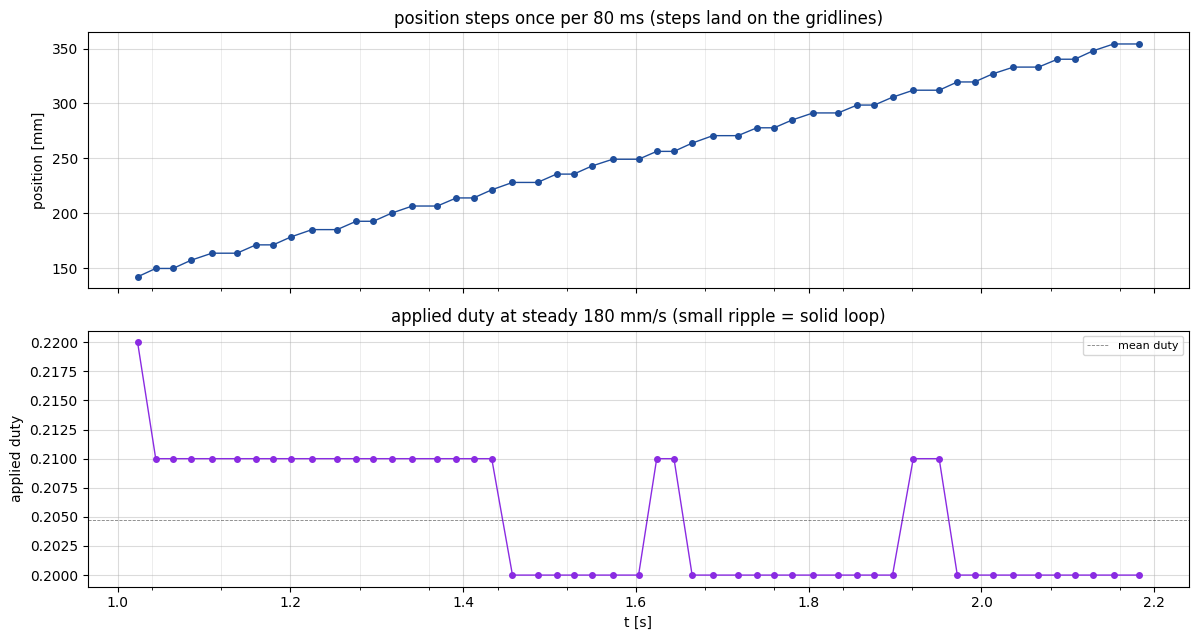

steady 180 mm/s: duty mean=0.205 std=0.005 range=0.200..0.220  (small std => steady loop is stable)


In [19]:
# steady drive to see the staircase + measure steady-state duty ripple
steady = stream_capture(rig, 1, lambda t: 0.0, duration=5.0, stream_ms=20, offset=180.0)
ts = arr(steady, "t"); m = (ts > 1.0) & (ts < 2.2)   # a clean 1.2s window
fig, ax = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)
ax[0].plot(ts[m], arr(steady,"pos")[m], color="#1f4e9c", lw=1.0, marker="o", ms=4)
ax[0].set_ylabel("position [mm]"); ax[0].set_title("position steps once per 80 ms (steps land on the gridlines)")
ax[1].plot(ts[m], arr(steady,"applied")[m], color="#8a2be2", lw=1.0, marker="o", ms=4)
ax[1].axhline(np.nanmean(arr(steady,"applied")[m]), color="k", lw=0.6, ls="--", alpha=0.5, label="mean duty")
ax[1].set_ylabel("applied duty"); ax[1].set_xlabel("t [s]")
ax[1].set_title("applied duty at steady 180 mm/s (small ripple = solid loop)"); ax[1].legend(fontsize=8)
for a in ax: grid80(a)
fig.tight_layout(); plt.show()
ap = arr(steady,"applied")[m]
print(f"steady 180 mm/s: duty mean={np.nanmean(ap):.3f} std={np.nanstd(ap):.3f} "
      f"range={np.nanmin(ap):.3f}..{np.nanmax(ap):.3f}  (small std => steady loop is stable)")

## Findings

- **Telemetry is fixed** — the goal of this pass. The `STREAM` push path is gap-free at the encoder's cadence; the
  earlier ragged, half-missing traces were the lossy per-sample **poll** path (request/reply lagging past the host
  timeout under load), not the sensor. The encoder + I2C are clean (0 I2C errors).
- **The "staircase" was an aliasing artifact** of fast-polling a slow (80 ms) encoder. Sampled honestly, position
  steps once per 80 ms, right on the gridlines.
- **The steady-state velocity loop is actually stable** (duty ~0.205 ± 0.005 at 180 mm/s). The dramatic audible chop
  earlier was dominated by deliberate rapid-reversal stress probing, not normal driving.
- **The 16 ms-tick / 80 ms-feedback rate mismatch is real but modest** — it adds duty motion mainly during fast
  command changes on the high-inertia drum. Gating the PID update on a fresh encoder sample (running the loop at the
  true ~12.5 Hz feedback rate) would tidy that up; it's a refinement to weigh, not an emergency.

In [20]:
rig.close()
print("done")

done
